# MCTS, UCT, and PUCT — two 2-player games, one search

**Objective:** watch one search — lazy expansion, UCT/PUCT selection, negamax backprop —
explain itself on two different games, then play against it yourself.

**The story:** rules for both games → pure UCT (no priors) → PUCT with hand-set priors →
what the exploration constant and tree reuse change → an opponent ladder and a tiny
self-play network → you play the search, live, on both games.

**What's ahead:**
- The rules and a strategy tip for each game, plus engine self-checks
- Pure UCT vs. PUCT with priors, stepped iteration by iteration
- How the exploration constant *c* reshapes the search
- Tree reuse: rerooting instead of restarting
- An opponent ladder and a tiny self-play network
- You vs. MCTS, on both games

**One-line Classic strategy:** center > corner > edge, and always block an immediate
three-in-a-row.

## The two games

**Classic tic-tac-toe.** Player 1 is X, player 2 is O. Turns alternate; first to place
three of their own mark in a row, column, or diagonal wins; a full board with no line is a
draw. *Strategy:* take the center if it's open, corners next, edges last; always block an
opponent's immediate three-in-a-row before doing anything else.

**Numerical (Graham) tic-tac-toe.** Same 3×3 grid, same win-by-line idea, but the marks
are numbers. Player 1 owns the five odd numbers {1,3,5,7,9}; player 2 owns the four even
numbers {2,4,6,8}. Each turn a player places one of their own remaining numbers into any
empty cell. The first line to sum to exactly 15 wins immediately — the three numbers in
that line can belong to either player. *Strategy:* for every open cell, notice which
number from your remaining pool would complete a 15 through it; prefer center and corners
for the same reason as Classic; and watch for lines that mix both players' numbers, since
those are the easiest to miss. With perfect play the first player (odds) wins.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("scripts"))

import random
from dataclasses import replace

import numpy as np
import matplotlib.pyplot as plt

import engine as eng
import mcts as mc
import viz
import scenarios as sc

plt.rcParams["figure.facecolor"] = "white"

## Engine self-checks

In [2]:
eng.self_check()

engine self-check passed
X | X | X
---------------
. | O | .
---------------
O | . | .
 9 |  4 |  2
---------------
 . |  . |  5
---------------
 . |  . |  .


## Baseline story: pure UCT vs. PUCT with priors (Classic)

Pure UCT and PUCT explore the identical opening completely differently within the same
10-iteration budget. Each dashboard below steps the first 6 iterations frame by frame;
**Next** keeps going through the remaining recorded frames to a final "search complete"
view, **Prev** steps back, **Reset** always jumps to iteration 1, selection.

**One MCTS iteration, in four steps:**
- **Selection** — from the root, repeatedly pick the highest-scoring action (tried or
  untried) until reaching a node with an untried action or a finished game.
- **Expansion** — if that action was untried, create the one new node for it (lazy
  expansion: the tree never grows past what's actually been explored).
- **Evaluation** — score the new leaf: a random rollout to a finished game, or a
  stand-in/learned value.
- **Backprop** — carry that value back up to the root, **flipping it (`v → 1 − v`) at
  every step**, since the two players alternate and rewards are constant-sum.

Selection scores exactly what's in `mcts.py`: UCT uses `Q + c·√(ln(N_parent+1)/N_child)`;
PUCT uses `Q + c·prior·√(N_parent+1)/(1+N_child)`.

**Reading the diagram:** green = this iteration's path · amber = the node just expanded ·
gold ring = current leader among the root's children (highest visits) · faint gray stubs =
untried actions · the root's children are grouped into three labelled bands, **CENTER /
CORNERS / EDGES**.

In [3]:
uct_mcts = sc.build_mcts(sc.SCENARIO_PURE_UCT)
uct_mcts.new_tree(eng.CLASSIC.initial_board())
uct_mcts.run(sc.SCENARIO_PURE_UCT.n_iterations, record=True)
viz.TreeBoardDashboard(eng.CLASSIC, viz.dashboard_frames(uct_mcts, 6),
                        uct_mcts.root().board, title="Pure UCT").display()

Output()

In [4]:
best_uct = uct_mcts.best_action("visits")
best_uct_child = uct_mcts.nodes[uct_mcts.root().children[best_uct]]
print(f"After 10 iterations, pure UCT's most-visited root move is "
      f"{best_uct_child.label(eng.CLASSIC)} with N={best_uct_child.N} (the gold ring "
      f"above) -- every legal move got tried at least once first.")

After 10 iterations, pure UCT's most-visited root move is X2 with N=2 (the gold ring above) -- every legal move got tried at least once first.


Same opening position, but with hand-set priors (center favored) and a stand-in value function instead of a random rollout:

In [5]:
puct_mcts = sc.build_mcts(sc.SCENARIO_PUCT_PRIOR)
puct_mcts.new_tree(eng.CLASSIC.initial_board())
puct_mcts.run(sc.SCENARIO_PUCT_PRIOR.n_iterations, record=True)
viz.TreeBoardDashboard(eng.CLASSIC, viz.dashboard_frames(puct_mcts, 6),
                        puct_mcts.root().board, title="PUCT + priors").display()

Output()

In [6]:
best_puct = puct_mcts.best_action("visits")
best_puct_child = puct_mcts.nodes[puct_mcts.root().children[best_puct]]
print(f"After the same 10 iterations, PUCT's most-visited root move is "
      f"{best_puct_child.label(eng.CLASSIC)} with N={best_puct_child.N} -- the prior "
      f"pulled most of the budget toward one line instead of spreading it across all nine.")

After the same 10 iterations, PUCT's most-visited root move is X4 with N=10 -- the prior pulled most of the budget toward one line instead of spreading it across all nine.


Side by side, after all 10 iterations:

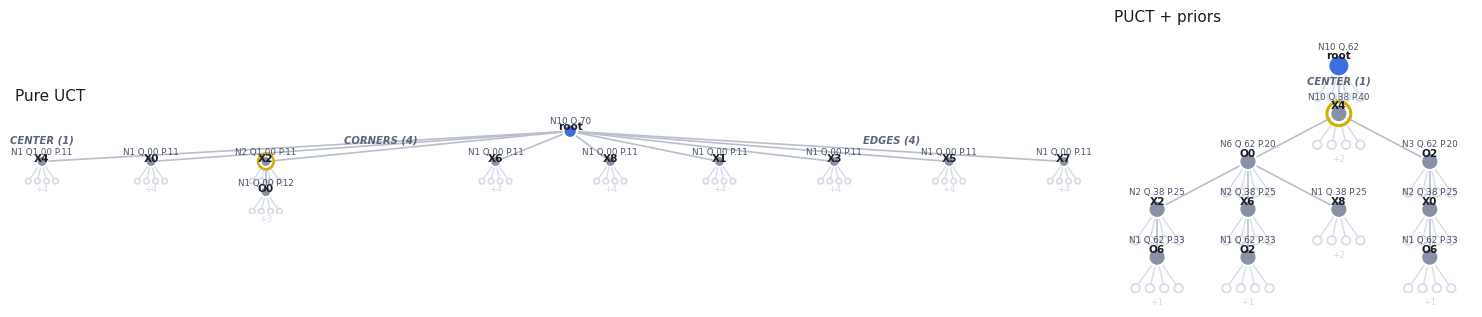

In [7]:
fig = viz.render_side_by_side(eng.CLASSIC,
    [("Pure UCT", uct_mcts), ("PUCT + priors", puct_mcts)])
plt.show()

Pure UCT's untried actions score `+inf`, so it always tries every legal move once before it deepens anywhere — a shallow fan after only 10 iterations. PUCT's exploration term is weighted by the prior instead, so it commits its early visits to the center almost immediately and pushes several moves deep down that one line.

## What the exploration constant c changes

Sweeping c holds everything else fixed (PUCT, the same hand-set priors, 10 iterations) and
tracks how concentrated the root's visits end up on its single most-visited move — low c
lets the prior dominate, high c spreads visits across more candidates.

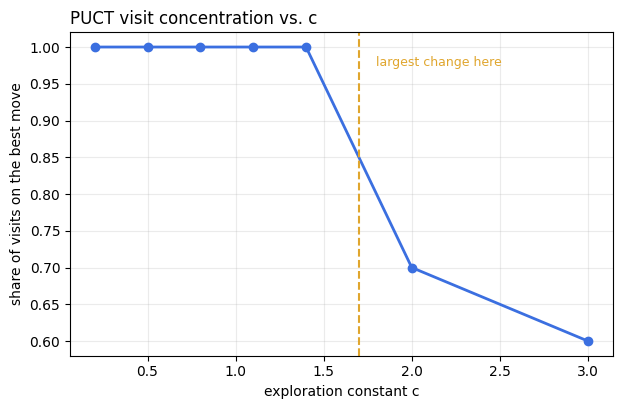

In [8]:
def visit_concentration(cfg):
    m = sc.build_mcts(cfg)
    m.new_tree(eng.CLASSIC.initial_board())
    m.run(cfg.n_iterations, record=False)
    visits = m.visit_distribution()
    total = sum(visits.values())
    return max(visits.values()) / total if total else 0.0

c_values = [0.2, 0.5, 0.8, 1.1, 1.4, 2.0, 3.0]
concentration = [visit_concentration(replace(sc.SCENARIO_PUCT_PRIOR, c=c)) for c in c_values]

viz.plot_parameter_sweep(c_values, concentration, xlabel="exploration constant c",
                          ylabel="share of visits on the best move",
                          title="PUCT visit concentration vs. c")
plt.show()

The dashed line marks where concentration changes fastest across this sweep — the point where the prior stops dominating and exploration starts actively competing with it for visits.

## Tree reuse: keep the subtree, don't start over

Rerooting onto the move MCTS actually played keeps the work it already paid for instead of
discarding it. Below: run 10 iterations, take MCTS's own best move, re-root onto the
resulting position and keep searching for 8 more — versus throwing the tree away and
starting a fresh 8-iteration search from the same position.

In [9]:
reuse_mcts = sc.build_mcts(replace(sc.SCENARIO_PUCT_PRIOR, n_iterations=10, seed=3))
reuse_mcts.new_tree(eng.CLASSIC.initial_board())
reuse_mcts.run(10, record=True)
viz.TreeBoardDashboard(eng.CLASSIC, viz.dashboard_frames(reuse_mcts, 5),
                        reuse_mcts.root().board, title="Before reroot (10 iterations)").display()

Output()

reroot carried 10 visits into the new root before the extra 8 iterations even ran
reused tree ends at N=18 total root visits; fresh tree ends at N=8


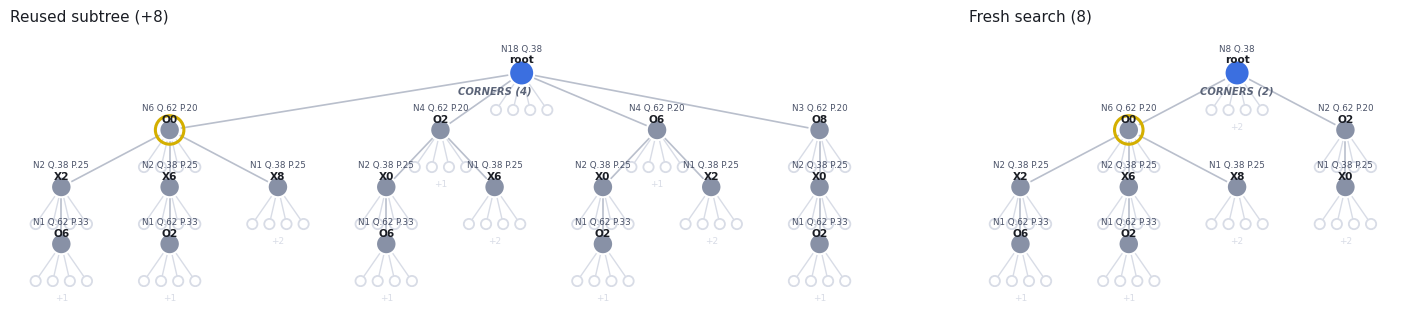

In [10]:
best = reuse_mcts.best_action("visits")
reused_visits = reuse_mcts.reroot(best)
reuse_mcts.run(8, record=False)

fresh_mcts = sc.build_mcts(replace(sc.SCENARIO_PUCT_PRIOR, n_iterations=8, seed=4))
fresh_mcts.new_tree(reuse_mcts.root().board)
fresh_mcts.run(8, record=False)

print(f"reroot carried {reused_visits} visits into the new root before the extra 8 "
      f"iterations even ran")
print(f"reused tree ends at N={reuse_mcts.root().N} total root visits; "
      f"fresh tree ends at N={fresh_mcts.root().N}")

fig = viz.render_side_by_side(eng.CLASSIC,
    [("Reused subtree (+8)", reuse_mcts), ("Fresh search (8)", fresh_mcts)])
plt.show()

The reused tree's extra 8 iterations build on top of visit counts the first search already paid for; the fresh tree spends all 8 of its iterations rediscovering ground the reused one covered for free.

## Opponent ladder

random → simple heuristic → weak MCTS (4 iterations) → strong MCTS (10 iterations), on
Classic. Each adjacent pair plays 16 games total, split evenly on who moves first, so
first-move advantage doesn't skew the read.

In [11]:
policies = [
    ("random", sc.random_policy),
    ("heuristic", sc.heuristic_policy),
    ("weak MCTS (4 it)", sc.make_mcts_policy(eng.CLASSIC, 4)),
    ("strong MCTS (10 it)", sc.make_mcts_policy(eng.CLASSIC, 10)),
]

rows = []
for i in range(len(policies) - 1):
    name_a, pol_a = policies[i]
    name_b, pol_b = policies[i + 1]
    w_ab = sc.round_robin_eval(eng.CLASSIC, {1: pol_a, 2: pol_b}, n_games=8, seed=10 + i)
    w_ba = sc.round_robin_eval(eng.CLASSIC, {1: pol_b, 2: pol_a}, n_games=8, seed=20 + i)
    rows.append((name_a, name_b, w_ab[1] + w_ba[2], w_ab[2] + w_ba[1], w_ab[0] + w_ba[0]))

header = f"{'A':<20}{'B':<20}{'A wins':>8}{'B wins':>8}{'draws':>8}"
print(header)
print("-" * len(header))
for name_a, name_b, a_wins, b_wins, draws in rows:
    print(f"{name_a:<20}{name_b:<20}{a_wins:>8}{b_wins:>8}{draws:>8}")

A                   B                     A wins  B wins   draws
----------------------------------------------------------------
random              heuristic                  0      13       3
heuristic           weak MCTS (4 it)          16       0       0
weak MCTS (4 it)    strong MCTS (10 it)       14       1       1


## AlphaZero-lite: self-play with a tiny network

A one-hidden-layer numpy network with policy and value heads, trained purely from its own
MCTS-guided self-play — 8 games, 8 MCTS iterations per move, on Classic. Watch the loss
fall as the network's raw guesses get pulled toward MCTS's improved visit distribution.

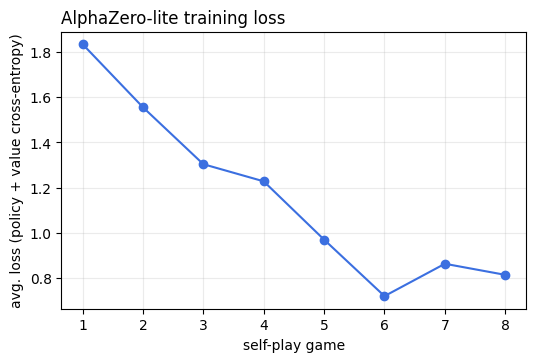

trained net's opening prior favors cell 5 (edge) at 0.77


In [12]:
net, losses = sc.self_play_training_loop(eng.CLASSIC, n_games=8, mcts_iterations=8, seed=5)

plt.figure(figsize=(6, 3.6))
plt.plot(range(1, len(losses) + 1), losses, marker="o", color=viz.COLOR_ROOT)
plt.xlabel("self-play game")
plt.ylabel("avg. loss (policy + value cross-entropy)")
plt.title("AlphaZero-lite training loss", loc="left")
plt.grid(alpha=0.25)
plt.show()

prior, value = net.predict(eng.CLASSIC.initial_board(), 1)
best_cell = max(prior, key=prior.get)
print(f"trained net's opening prior favors cell {best_cell} "
      f"({eng.cell_type(best_cell)}) at {prior[best_cell]:.2f}")

Eight games is nowhere near enough to train a strong network — this is a mechanism demo, not a strength demo — but the loss curve's direction and where the opening prior lands are both real outputs of real gradient steps, not staged.

## Play Classic against MCTS

This is the same PUCT search from above, now reacting to whatever you actually play. You're
X (player 1); MCTS gets 10 iterations per move, and the status line below the board flags
any immediate threat your move creates before the computer responds.

In [13]:
def classic_mcts_factory():
    return mc.MCTS(eng.CLASSIC, mc.make_uct_selector(1.4),
                    mc.make_random_rollout_eval(random.Random()),
                    mc.uniform_prior, seed=random.randint(0, 2**31 - 1))

viz.build_human_vs_mcts(eng.CLASSIC, classic_mcts_factory, human_player=1, computer_iterations=10)

## Play Numerical against MCTS — the climax

The identical search code plays a completely different-feeling game once the win condition
becomes arithmetic instead of geometric. You're player 1 (odds): click a cell, then pick
which of your remaining numbers to place there; MCTS gets 12 iterations per move, and the
same threat scan now watches for lines that sum to 15.

In [14]:
def numerical_mcts_factory():
    return mc.MCTS(eng.NUMERICAL, mc.make_uct_selector(1.4),
                    mc.make_random_rollout_eval(random.Random()),
                    mc.uniform_prior, seed=random.randint(0, 2**31 - 1))

viz.build_human_vs_mcts(eng.NUMERICAL, numerical_mcts_factory, human_player=1, computer_iterations=12)

## What you just saw

Two games, one search: the same lazy-expansion tree, the same UCT/PUCT selection rule, the
same scalar negamax backprop, driving both a hand-analyzed opening and a live opponent.
Priors reshaped where the search spent its budget; c controlled how much it trusted them;
rerooting carried earlier work forward instead of discarding it; and a network trained
purely on its own self-play started to develop an opening preference of its own.

**Open question:** Numerical tic-tac-toe has a known forced win for the first player. Did
the network's self-play prior on the opening move end up pointing toward it — or somewhere
else entirely?